## Configurando Ambiente e Importando Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, precision_recall_curve, roc_curve, 
                             roc_auc_score, average_precision_score, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## Subindo dados e Engenharia de Atributos

In [4]:
df = pd.read_csv('telofonia_churn.csv')
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# Features
df['intensidade_reclamacao'] = df['complaints_last_3m'] + df['outages_last_3m']
df['alerta_financeiro'] = df['late_payments_last_6m'] + (df['discount_pct'] / 100)
df['custo_beneficio'] = df['monthly_charges'] / (df['avg_download_mbps'] + 0.1)

if 'customer_id' in df.columns: df.drop(columns=['customer_id'], inplace=True)
df = df.fillna(df.median(numeric_only=True))

print(f"Dados prontos: {df.shape[0]} linhas.")

Dados prontos: 6000 linhas.


## Dashboard para de Análise de Proporçao de Churn

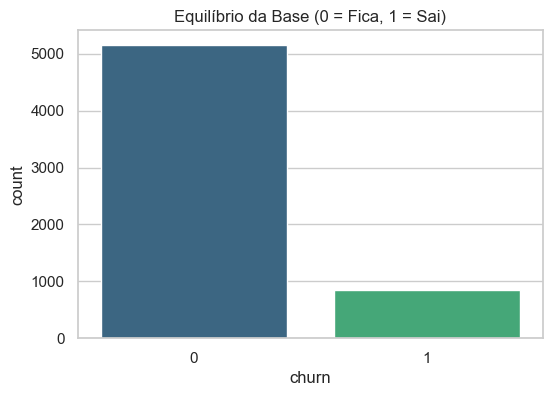

Proporção Churn:
churn
0    85.95
1    14.05
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Equilíbrio da Base (0 = Fica, 1 = Sai)')
plt.show()

print(f"Proporção Churn:\n{df['churn'].value_counts(normalize=True) * 100}")

## Pipeline de Processamento e Balanceamento

In [6]:
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', ImbPipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

resampler = ImbPipeline(steps=[
    ('pre', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=42))
])

X_res, y_res = resampler.fit_resample(X_train, y_train)
X_test_proc = resampler.named_steps['pre'].transform(X_test)
print("Dados balanceados e processados.")

Dados balanceados e processados.


## Treinamento do Modelo e Curva de Aprendizado

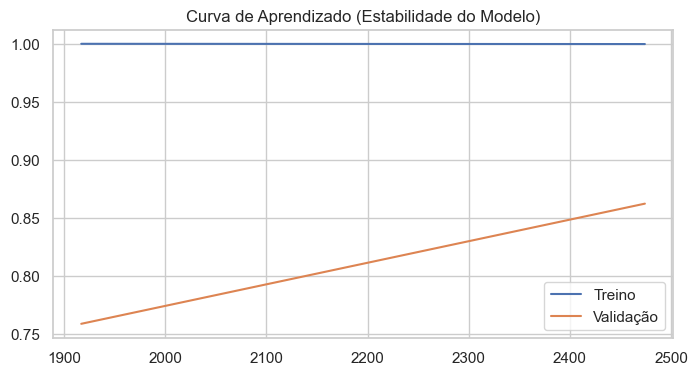

In [7]:
model_rf = RandomForestClassifier(n_estimators=500, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf.fit(X_res, y_res)

train_sizes, train_scores, test_scores = learning_curve(model_rf, X_res, y_res, cv=3, scoring='roc_auc', n_jobs=-1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Treino')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validação')
plt.title('Curva de Aprendizado (Estabilidade do Modelo)')
plt.legend()
plt.show()

## Avaliação Final de Performance com Matriz de Confusao

ROC-AUC FINAL: 0.7304


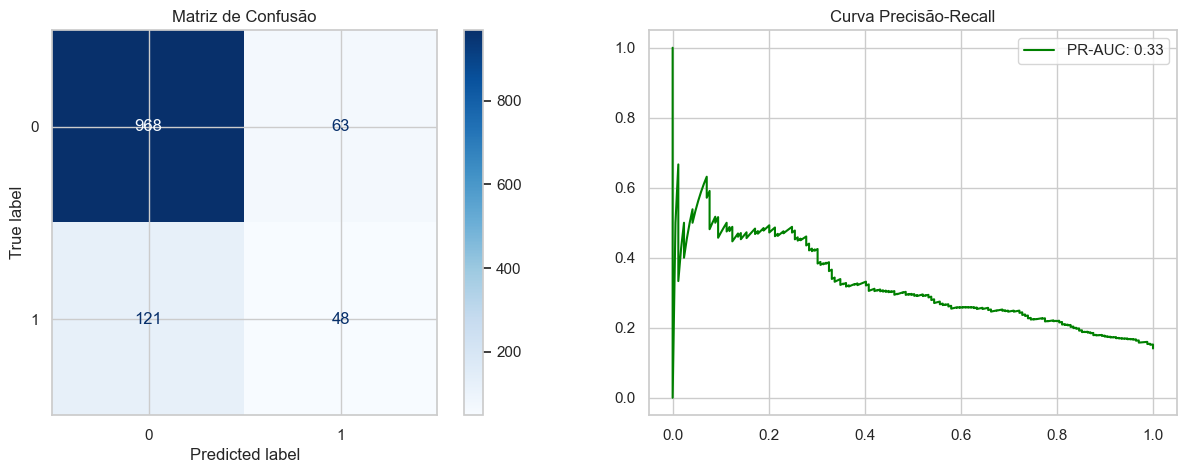

In [8]:
y_pred = model_rf.predict(X_test_proc)
y_prob = model_rf.predict_proba(X_test_proc)[:, 1]

print(f"ROC-AUC FINAL: {roc_auc_score(y_test, y_prob):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão")

prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax[1].plot(rec, prec, color='green', label=f'PR-AUC: {average_precision_score(y_test, y_prob):.2f}')
ax[1].set_title("Curva Precisão-Recall")
ax[1].legend()
plt.show()

## Análise de Roc e Probabalidade de Churn em Classes

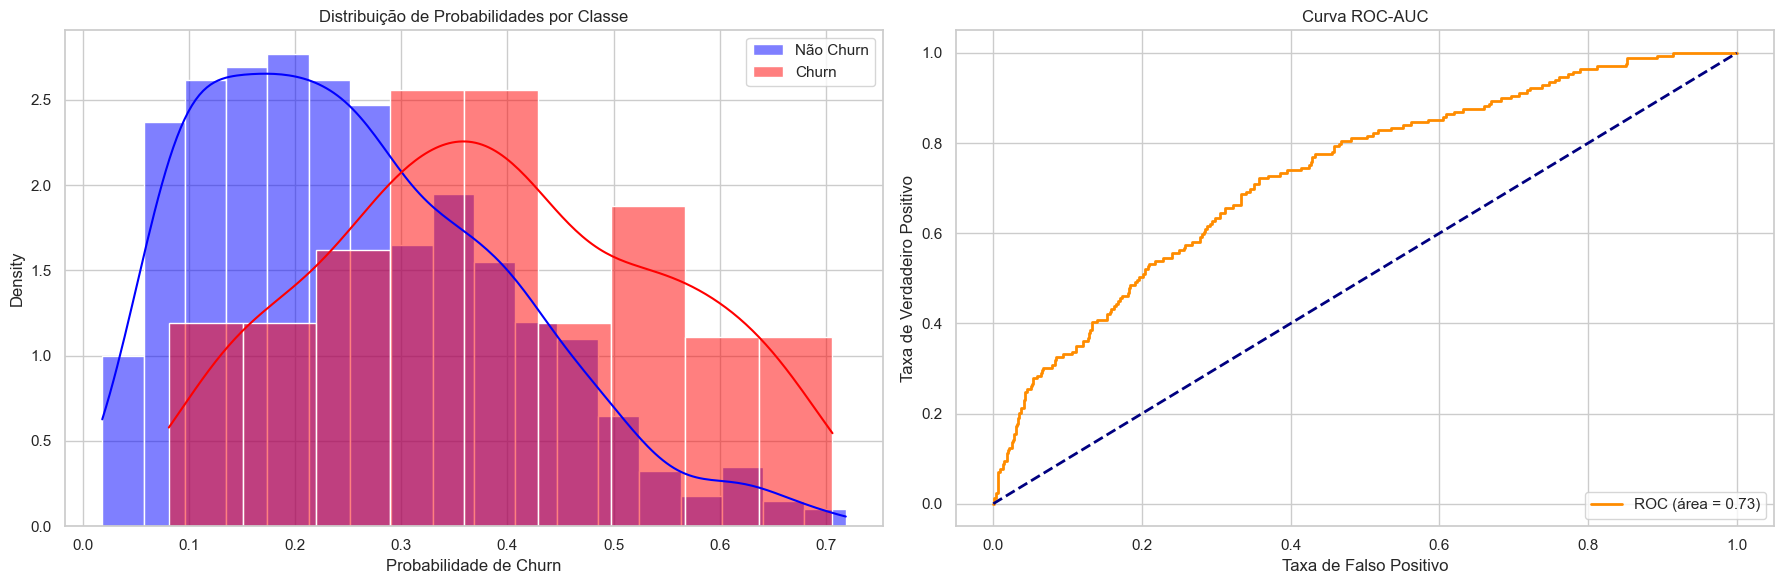

In [9]:
# Dashboard de Diagnóstico de Probabilidades
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Distribuição de Probabilidades (Histograma de Densidade)
sns.histplot(y_prob[y_test == 0], color="blue", label="Não Churn", kde=True, ax=ax[0], stat="density", alpha=0.5)
sns.histplot(y_prob[y_test == 1], color="red", label="Churn", kde=True, ax=ax[0], stat="density", alpha=0.5)
ax[0].set_title('Distribuição de Probabilidades por Classe')
ax[0].set_xlabel('Probabilidade de Churn')
ax[0].legend()

# Subplot 2: Curva ROC (Poder de Discriminação)
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (área = {roc_auc_score(y_test, y_prob):.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('Curva ROC-AUC')
ax[1].set_xlabel('Taxa de Falso Positivo')
ax[1].set_ylabel('Taxa de Verdadeiro Positivo')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Insights de Negócio: Descobrindo os Principais Churns

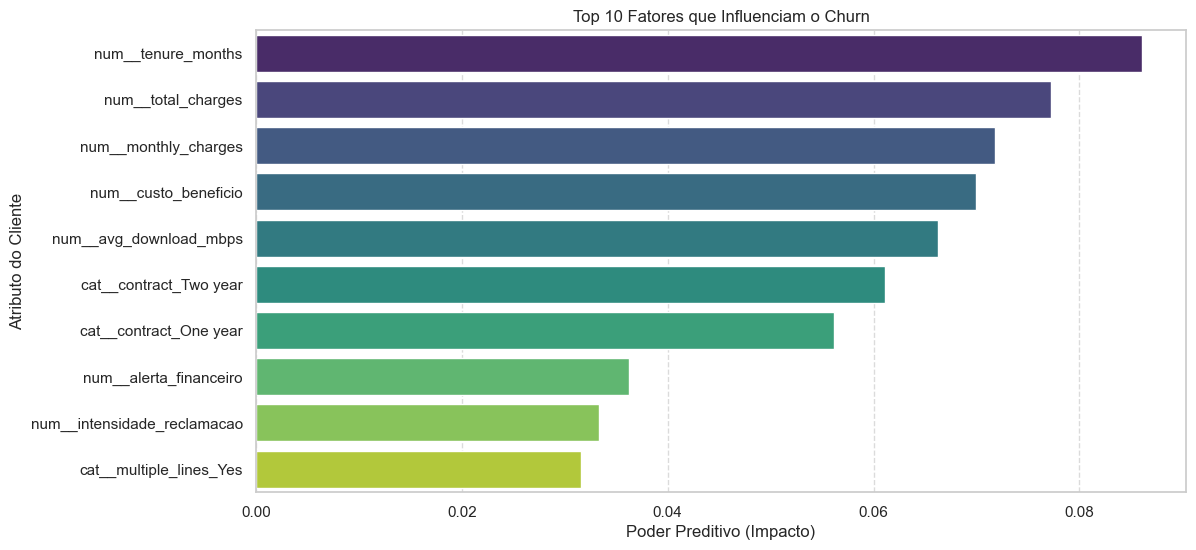

Insight: O fator 'num__tenure_months' é o principal driver de cancelamento.


In [10]:
# Extração de Importância dos Atributos
importances = model_rf.feature_importances_
feature_names = resampler.named_steps['pre'].get_feature_names_out()
feature_importance_df = pd.DataFrame({'Atributo': feature_names, 'Importância': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importância', ascending=False).head(10)

# Visualização
plt.figure(figsize=(12, 6))
sns.barplot(x='Importância', y='Atributo', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Fatores que Influenciam o Churn')
plt.xlabel('Poder Preditivo (Impacto)')
plt.ylabel('Atributo do Cliente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Insight Final por Texto
print(f"Insight: O fator '{feature_importance_df.iloc[0]['Atributo']}' é o principal driver de cancelamento.")

## Impacto do Modelo de Negócio: Churn por Tipo Contrato

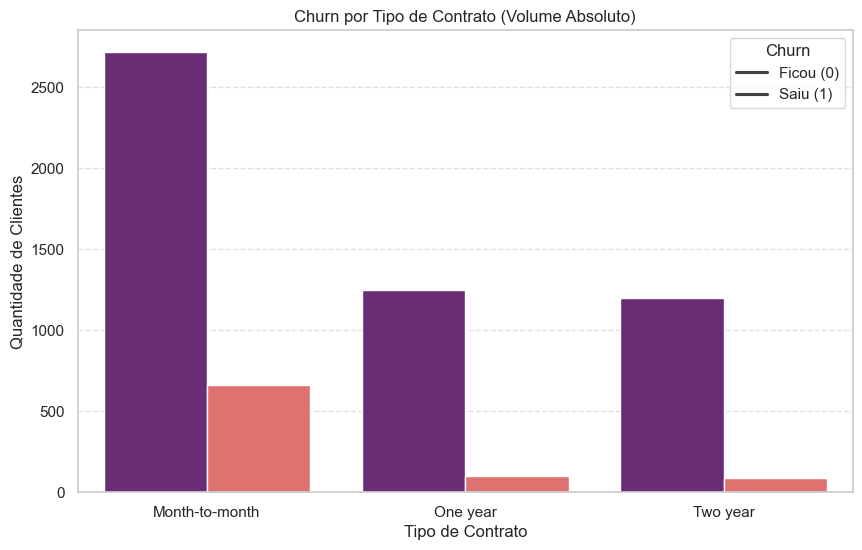

---Taxa de Churn por Contrato ---
One year: 7.23% de taxa de cancelamento
Month-to-month: 19.57% de taxa de cancelamento
Two year: 6.64% de taxa de cancelamento


In [11]:
# Criando o Dashboard de Contratos
plt.figure(figsize=(10, 6))

# Agrupando os dados para o gráfico de barras comparativo
contract_churn = df.groupby(['contract', 'churn']).size().reset_index(name='contagem')

# Plotando a relação
sns.barplot(x='contract', y='contagem', hue='churn', data=contract_churn, palette='magma')

plt.title('Churn por Tipo de Contrato (Volume Absoluto)')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Churn', labels=['Ficou (0)', 'Saiu (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Cálculo da Taxa de Churn por Categoria para Insight
print("---Taxa de Churn por Contrato ---")
for contrato in df['contract'].unique():
    subset = df[df['contract'] == contrato]
    taxa = (subset['churn'].mean() * 100)
    print(f"{contrato}: {taxa:.2f}% de taxa de cancelamento")